# Crop Prediction using Machine Learning 

**Dataset:** Soil & climate features mapped to 22 African crop types  
**Goal:** Train and compare three ML classifiers, select the best, and deploy with Streamlit  
**Columns:** `N`, `P`, `K` (soil nutrients), `temperature`, `ph`, `rainfall` -> `crop` (target)


In [1]:
# Import necessary libraries for data manipulation, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})


## 1. Data Loading & Inspection

In [4]:
# Load dataset
df = pd.read_excel("DATA CROP.xlsx") 
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Shape: 2,200 rows × 7 columns


,N,P,K,temperature,ph,rainfall,crop
0,90,42,43,20.879744,6.502985,202.935536,rice
1,85,58,41,21.770462,7.038096,226.655537,rice
2,60,55,44,23.004459,7.840207,263.964248,rice
3,74,35,40,26.491096,6.980401,242.864034,rice
4,78,42,42,20.130175,7.628473,262.717340,rice


In [5]:
# Basic info on the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   ph           2200 non-null   float64
 5   rainfall     2200 non-null   float64
 6   crop         2200 non-null   object 
dtypes: float64(3), int64(3), object(1)
memory usage: 120.4+ KB


In [6]:
# Statistical summary on the dataset
df.describe().round(3)


,N,P,K,temperature,ph,rainfall
count,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000
mean,53.679,52.294,51.435,25.866,6.439,103.464
std,39.799,33.104,55.904,4.896,1.856,54.958
min,0.000,5.000,5.000,8.826,3.505,20.211
25%,21.000,27.000,20.000,23.189,5.909,64.552
50%,38.000,48.000,32.000,25.738,6.388,94.868
75%,89.000,67.000,49.000,28.578,6.853,124.268
max,179.000,145.000,250.000,43.675,86.000,298.560


### Macronutrients (N: Nitrogen, P: Phosphorus, K: Potassium):

**N (Nitrogen):** Mean 53.7, ranges 0–179. Wide spread (std 39.8) indicates diverse soil conditions

**P (Phosphorus):** Mean 52.3, ranges 5–145. More concentrated than N (std 33.1)

**K (Potassium):** Mean 51.4, ranges 5–250. Highest variability (std 55.9), with extreme values suggesting diverse crops/regions

<br/>

### Environmental Factors:

**Temperature:** Mean 25.9°C, ranges 8.8–43.7°C. Low std (4.9) = consistent climate zone. 50% of data falls between 23–28.6°C

**pH:** Mean 6.4 (slightly acidic). Concerning: range includes 3.5–86, with max value (86) being an outlier, normal soil pH is 3–9

**Rainfall:** Mean 103.5mm, ranges 20–298.6mm. Std of 55mm shows moderate variation in precipitation patterns

<br/>

### Data Characteristics

**Right-skewed distributions:** Most variables show mean > median (50%), indicating longer upper tails (outliers on high end)

**Outliers present:** pH max of 86 is unrealistic and should be investigated

**Good diversity:** Wide ranges suggest the dataset covers multiple crops, seasons, and geographic regions

In [7]:
# Missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing: {missing.sum()}")


Missing values per column:
N              0
P              0
K              0
temperature    0
ph             0
rainfall       0
crop           0
dtype: int64

Total missing: 0


There are no missing values in the dataset, and it contains 2200 rows and 7 columns. The target variable `crop` has 22 unique classes, with a fairly balanced distribution across them. The features include soil nutrients (N, P, K), temperature, pH, and rainfall, which are all relevant for predicting crop types.

In [8]:
# Class distribution
print(f"Unique crops : {df['crop'].nunique()}")
print("\nCrop value counts:")
print(df['crop'].value_counts())


Unique crops : 22

Crop value counts:
crop
rice                100
maize               100
coffee              100
jute/ewedu          100
cotton              100
coconut             100
pawpaw              100
orange              100
palm tree           100
muskmelon           100
watermelon          100
grapes              100
mango               100
banana              100
cashew              100
beni/sesame seed    100
black beans         100
mungbean            100
mothbeans           100
pigeonpeas          100
kidneybeans         100
potato              100
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)

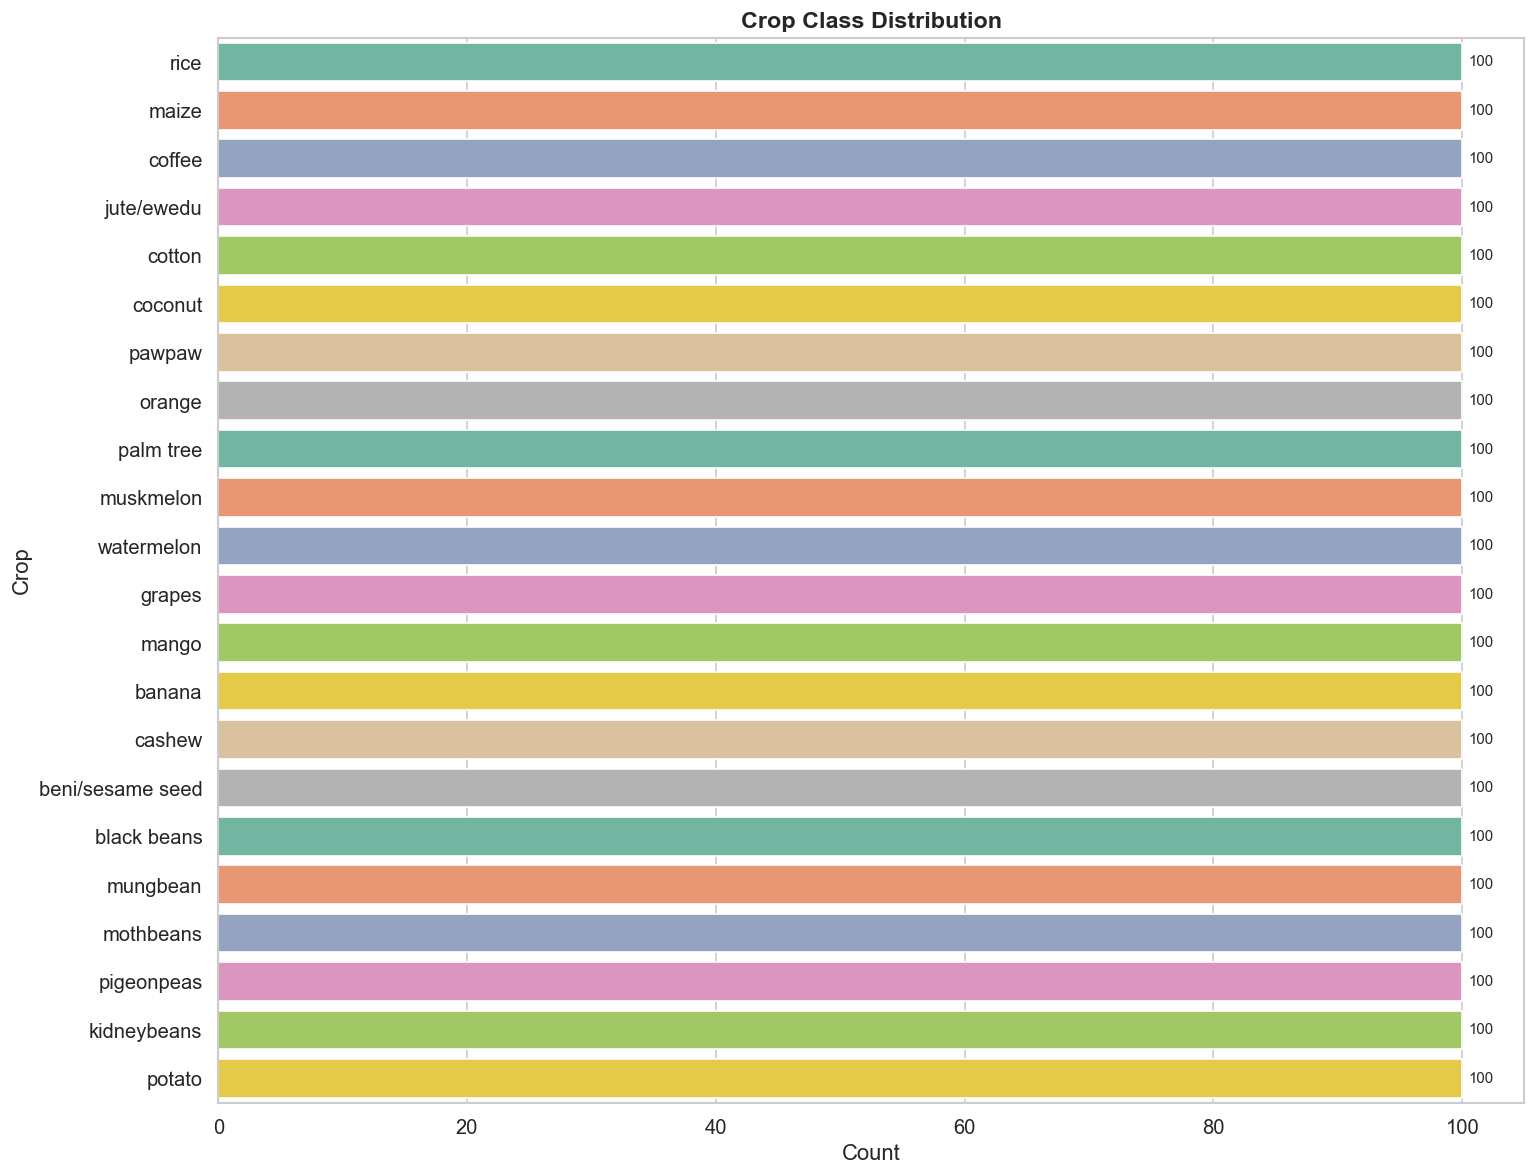

In [11]:
# Crop class distribution bar chart
fig, ax = plt.subplots(figsize=(13, 10))
order = df['crop'].value_counts().index
sns.countplot(data=df, y='crop', order=order, palette='Set2', ax=ax)
ax.set_title("Crop Class Distribution", fontsize=14, fontweight='bold')
ax.set_xlabel("Count")
ax.set_ylabel("Crop")
for bar in ax.patches:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


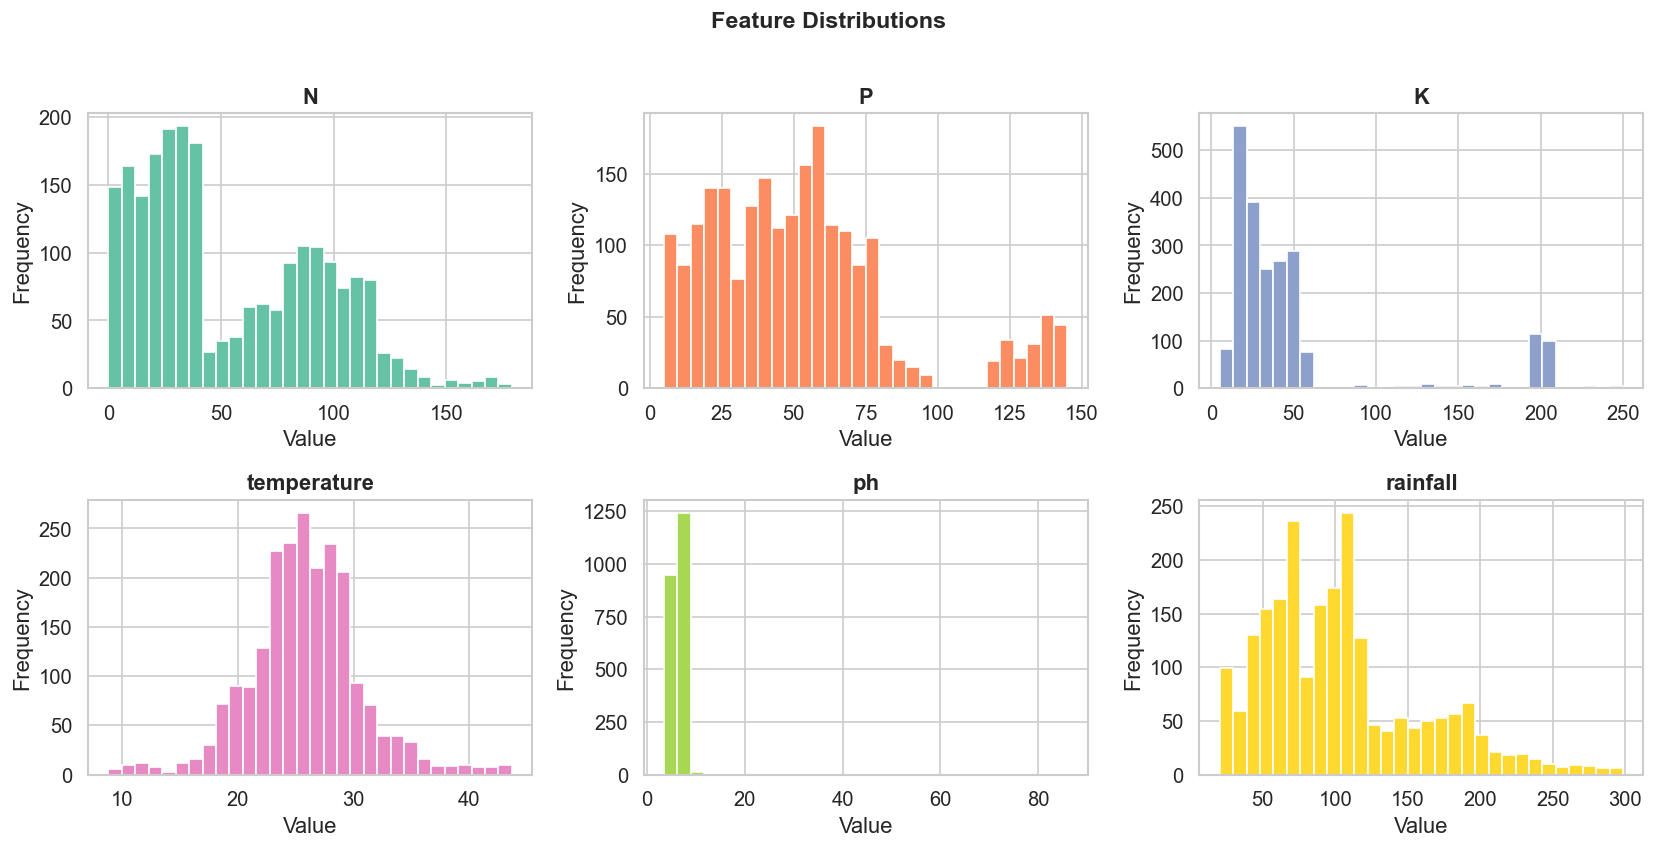

In [12]:
# Feature distributions (histograms)
features = ['N', 'P', 'K', 'temperature', 'ph', 'rainfall']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color=sns.color_palette("Set2")[i], edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
plt.suptitle("Feature Distributions", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**N (Nitrogen):** it is right-skewed with most crops needing low-to-moderate nitrogen (0–50 range). A secondary cluster around 80–130 represents high-nitrogen-demanding crops like banana, coffee, and potato. The bimodal shape is a strong signal that N is a highly discriminative feature.

**P (Phosphorus):** Roughly bell-shaped but with a suspicious gap between ~100–125, then a second cluster at 125–145. That high-P cluster is almost certainly grapes and muskmelon (confirmed by P Levels per Crop). P has good class-separating power.

**K (Potassium):** Highly right-skewed — the vast majority of crops sit in 5–60, with a very sparse but significant tail at 200+. Those extreme K values belong to grapes and muskmelon. K is one of the most discriminative features in the dataset precisely because of this.

**Temperature:** Near-normal distribution centred around 25°C, ranging 8–44°C. The reasonably Gaussian shape means most crops share similar temperature ranges, making it a weaker standalone feature, but it still contributes in combination (e.g. pawpaw uniquely extends to 40°C+).

**pH:** This is the most important observation, the chart is dominated by two towering bars near 0–10, with the x-axis stretching all the way to 80+. This is the visual proof of the outlier (pH = 86) that needs to be cleaned. After cleaning, pH is actually a tight, fairly normal distribution around 6.0–7.5, which is typical agronomic range.

**Rainfall:** Bimodal distribution with peaks around 60–70mm and 95–105mm, then a smaller cluster near 200–210mm. Rice (very high rainfall ~200–300mm) and muskmelon (very low rainfall ~30–40mm) sit at the extremes, making rainfall one of the most class-separating features.

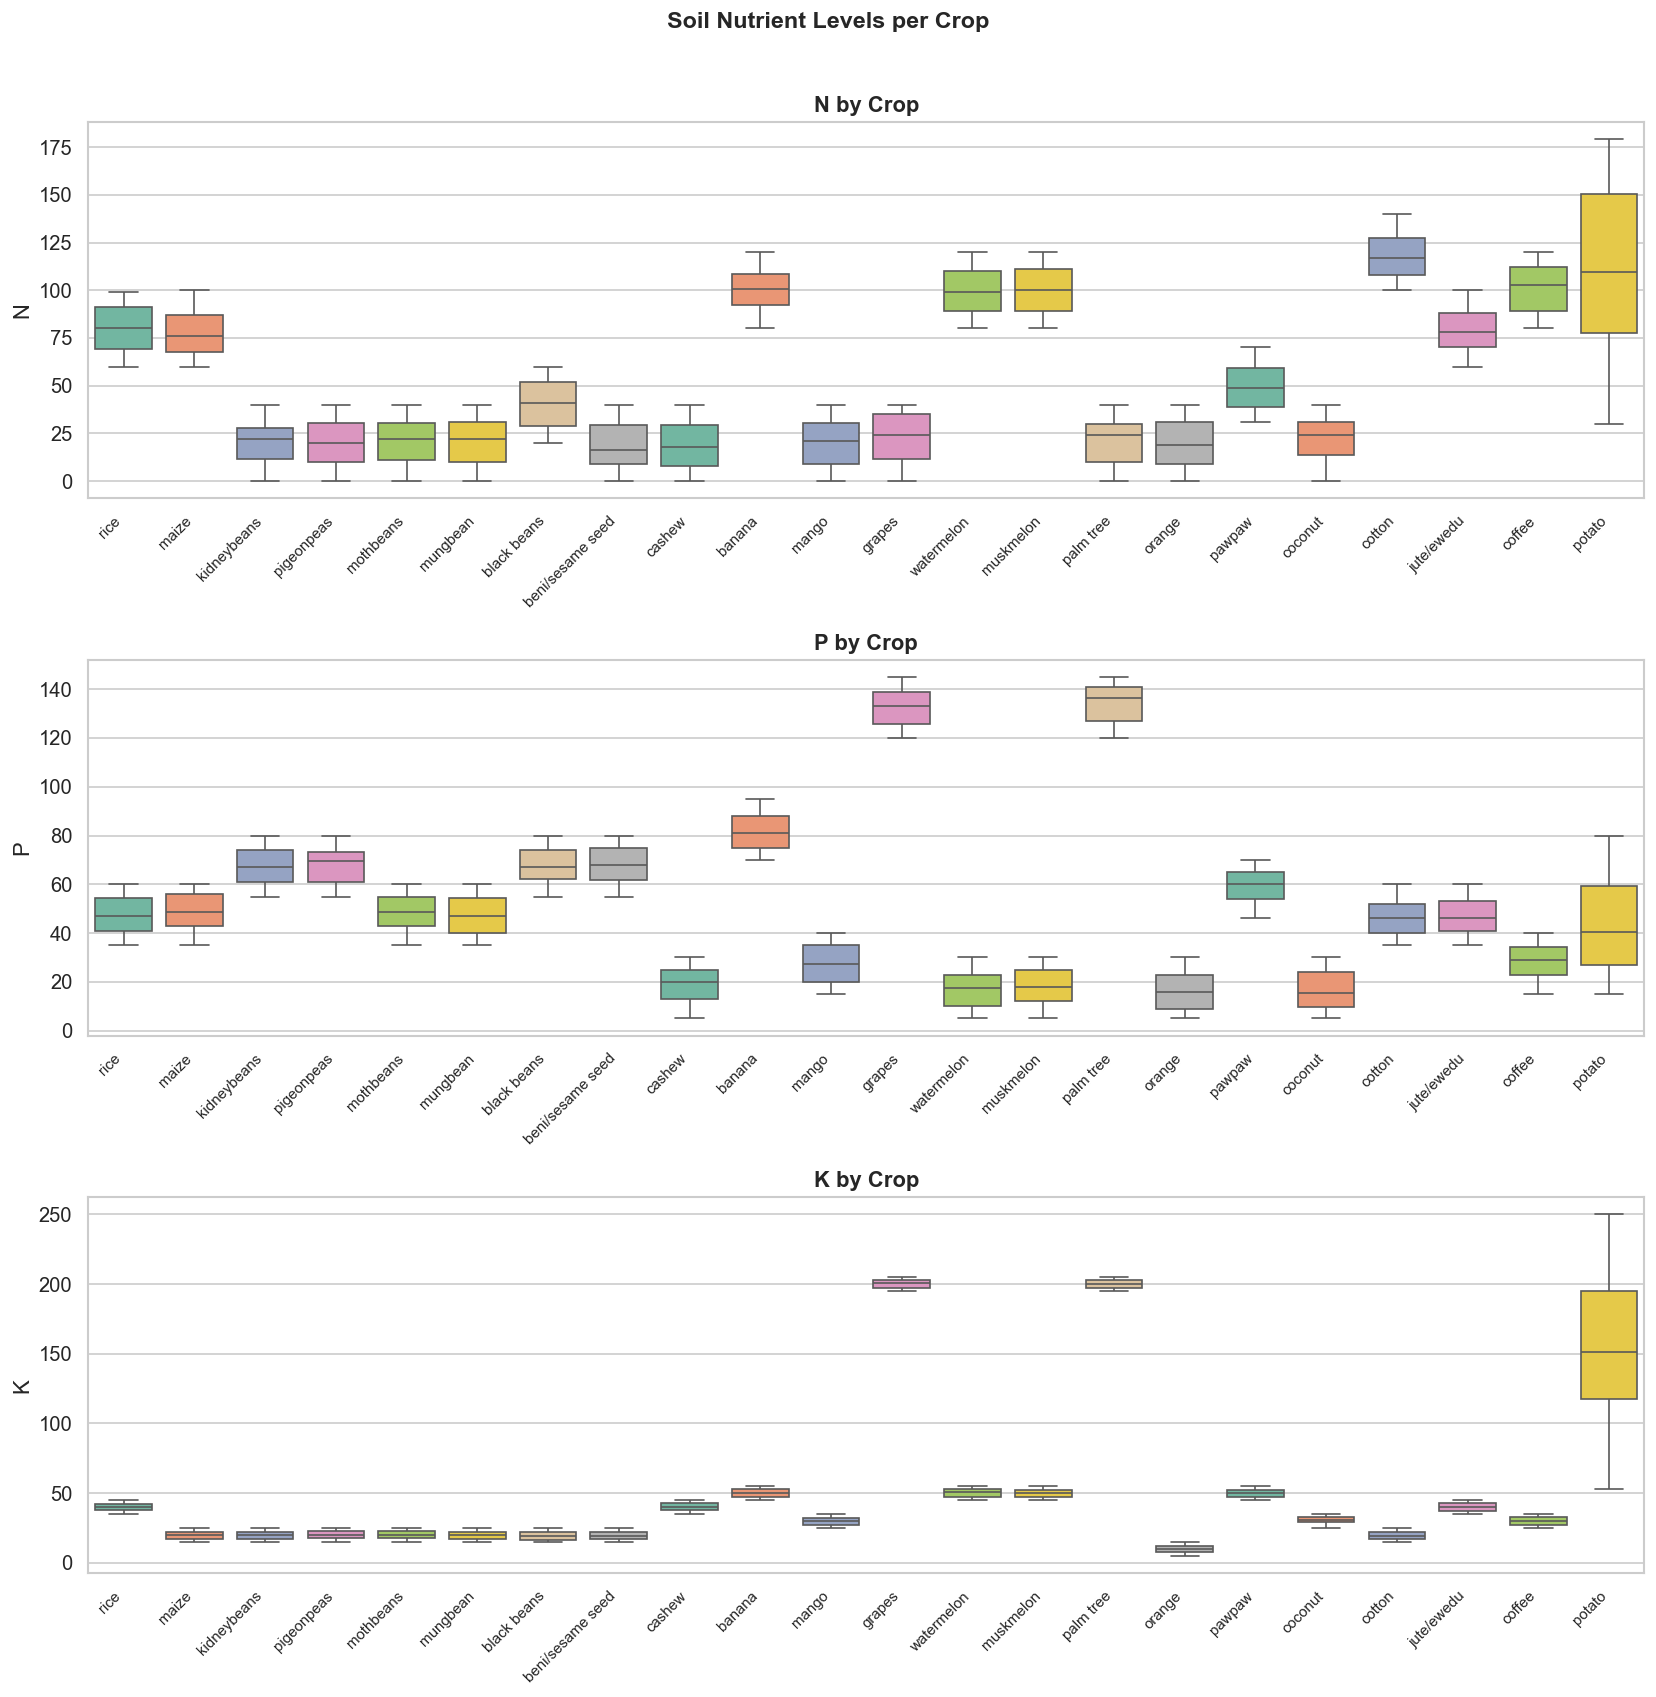

In [13]:
# Boxplots by crop (N, P, K)
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
for ax, col in zip(axes, ['N', 'P', 'K']):
    sns.boxplot(data=df, x='crop', y=col, palette='Set2', ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{col} by Crop', fontweight='bold')
    ax.set_xlabel("")
plt.suptitle("Soil Nutrient Levels per Crop", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**N by Crop:** Three tiers are clearly visible. Low-N crops (5–30): kidney beans, pigeonpeas, mothbeans, mungbean, beni/sesame seed, cashew, mango, palm tree, orange, jute/ewedu, coffee. Mid-N crops (70–90): rice, maize. High-N crops (90–120+): banana, grapes, watermelon, muskmelon, cotton, coconut, potato. Potato has the widest N range (IQR ~100–150), suggesting high variability in its nitrogen needs.

**P by Crop:** The standout observation is grapes (~130–140) and muskmelon (~130–140), they have dramatically higher phosphorus requirements than every other crop. This makes P an excellent separator for those two classes. Most other crops cluster between 15–80, with banana (~80) being the next highest.

**K by Crop:** The most striking chart — grapes and muskmelon again shoot to ~200, completely separated from the rest of the dataset. Potato also has a very wide range (50–250), suggesting it can tolerate varying potassium levels. All other crops are tightly packed at 5–55. This means K will be one of the most important features in the model, which is later confirmed by the feature importance plot.

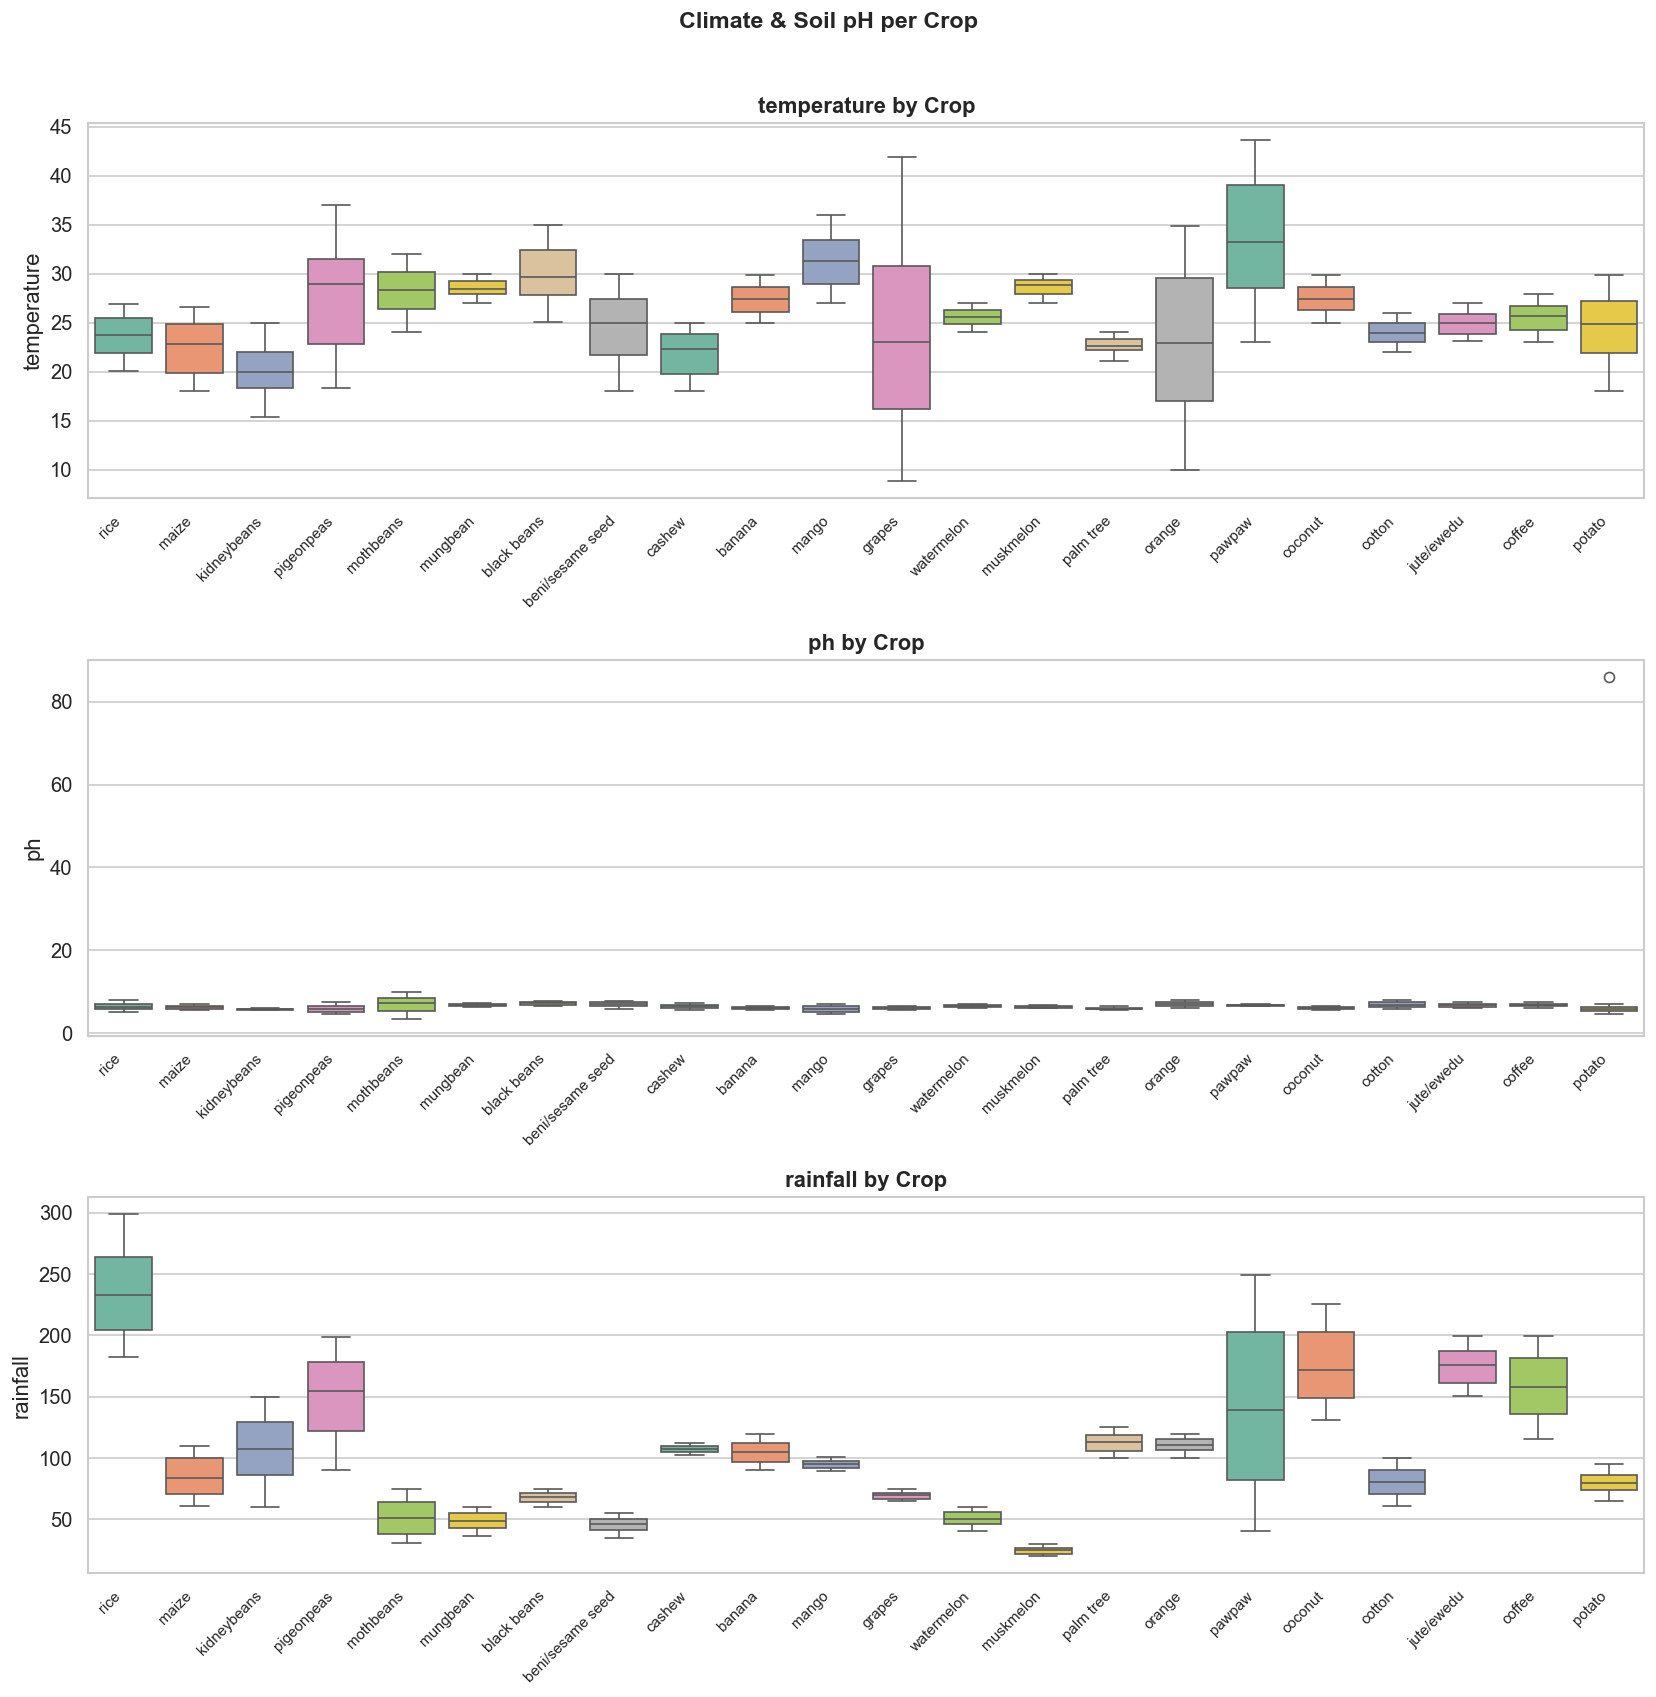

In [14]:
# Boxplots (temperature, ph, rainfall)
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
for ax, col in zip(axes, ['temperature', 'ph', 'rainfall']):
    sns.boxplot(data=df, x='crop', y=col, palette='Set2', ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{col} by Crop', fontweight='bold')
    ax.set_xlabel("")
plt.suptitle("Climate & Soil pH per Crop", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Temperature by Crop:** Most crops sit in a 20–32°C band. Pawpaw is the outlier with a wide IQR reaching up to ~40°C, suggesting it thrives in hotter conditions. Grapes has the widest spread (13–40°C), making temperature a weaker separator for it. Kidney beans and maize are distinctly cooler (~20–24°C). Pigeon peas, mothbeans, beni/sesame seed are clearly hot-weather crops (28–32°C).

**pH by Crop:** Almost all the boxplots are flattened into a thin horizontal band at pH 5–8, which is the cleaned, realistic range. The single white circle above 80 in the potato column is the remaining outlier point, the one entry that survived or was not yet removed at that point in the plot. This confirms that cleaning will be necessary and effective. The practical implication is that pH alone is a poor discriminator between crops since nearly all crops share a similar optimal range.

**Rainfall by Crop:** This is arguably the most informative chart in the set. Rice stands far above every other crop (200–300mm), making it immediately identifiable by rainfall alone. Muskmelon and watermelon sit at the very bottom (30–70mm), being drought-tolerant crops. Mothbeans and beni/sesame seed also need very little rain (~45–65mm). Coconut, cotton, and jute/ewedu need moderate-to-high rainfall (150–200mm). This clear separation means rainfall will rank high in feature importance.

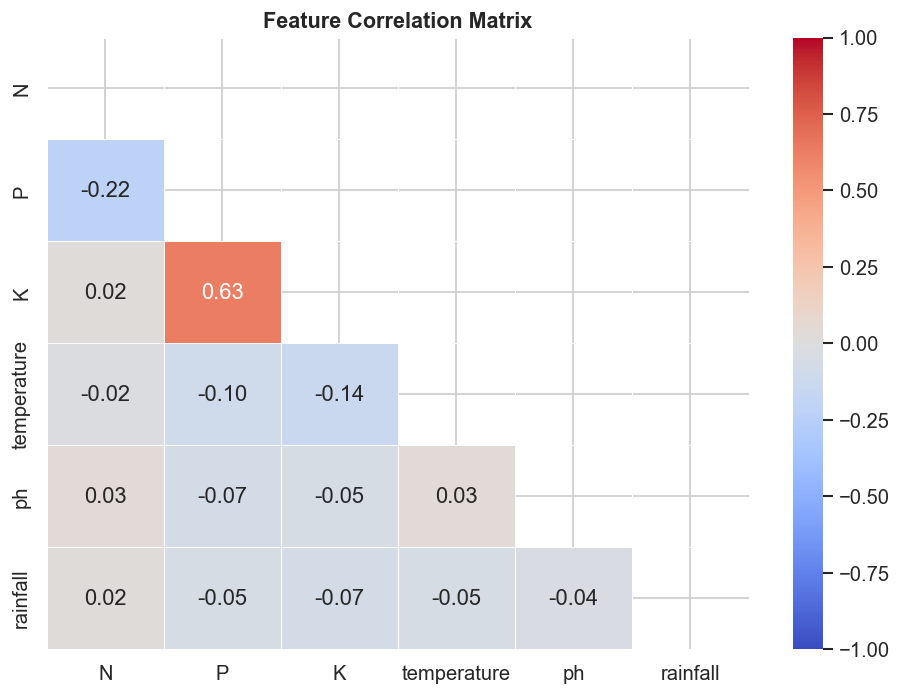

In [15]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', mask=mask,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


The most important takeaway here is that all features are nearly uncorrelated with each other, which is excellent news for the models.

**P ↔ K (r = 0.63):** The only meaningful correlation in the dataset. Phosphorus and potassium tend to co-occur at high levels, this makes sense agronomically since the same soil conditions (e.g. heavy fertilisation) that raise P often raise K. However, 0.63 is moderate, not high enough to cause multicollinearity problems.

**N ↔ P (r = −0.22):** A slight negative relationship — crops that need high nitrogen tend to need lower phosphorus and vice versa. This also reflects the natural split between leguminous crops (fix nitrogen, low N-demand) and fruiting crops (high P-demand).

**All other pairs (r < 0.15):** Temperature, pH, and rainfall are essentially independent of the soil nutrients and of each other. This is very good because it means each feature is contributing unique, non-redundant information to the model, which is one reason Random Forest achieves such high accuracy — it can exploit all 6 features without interference.

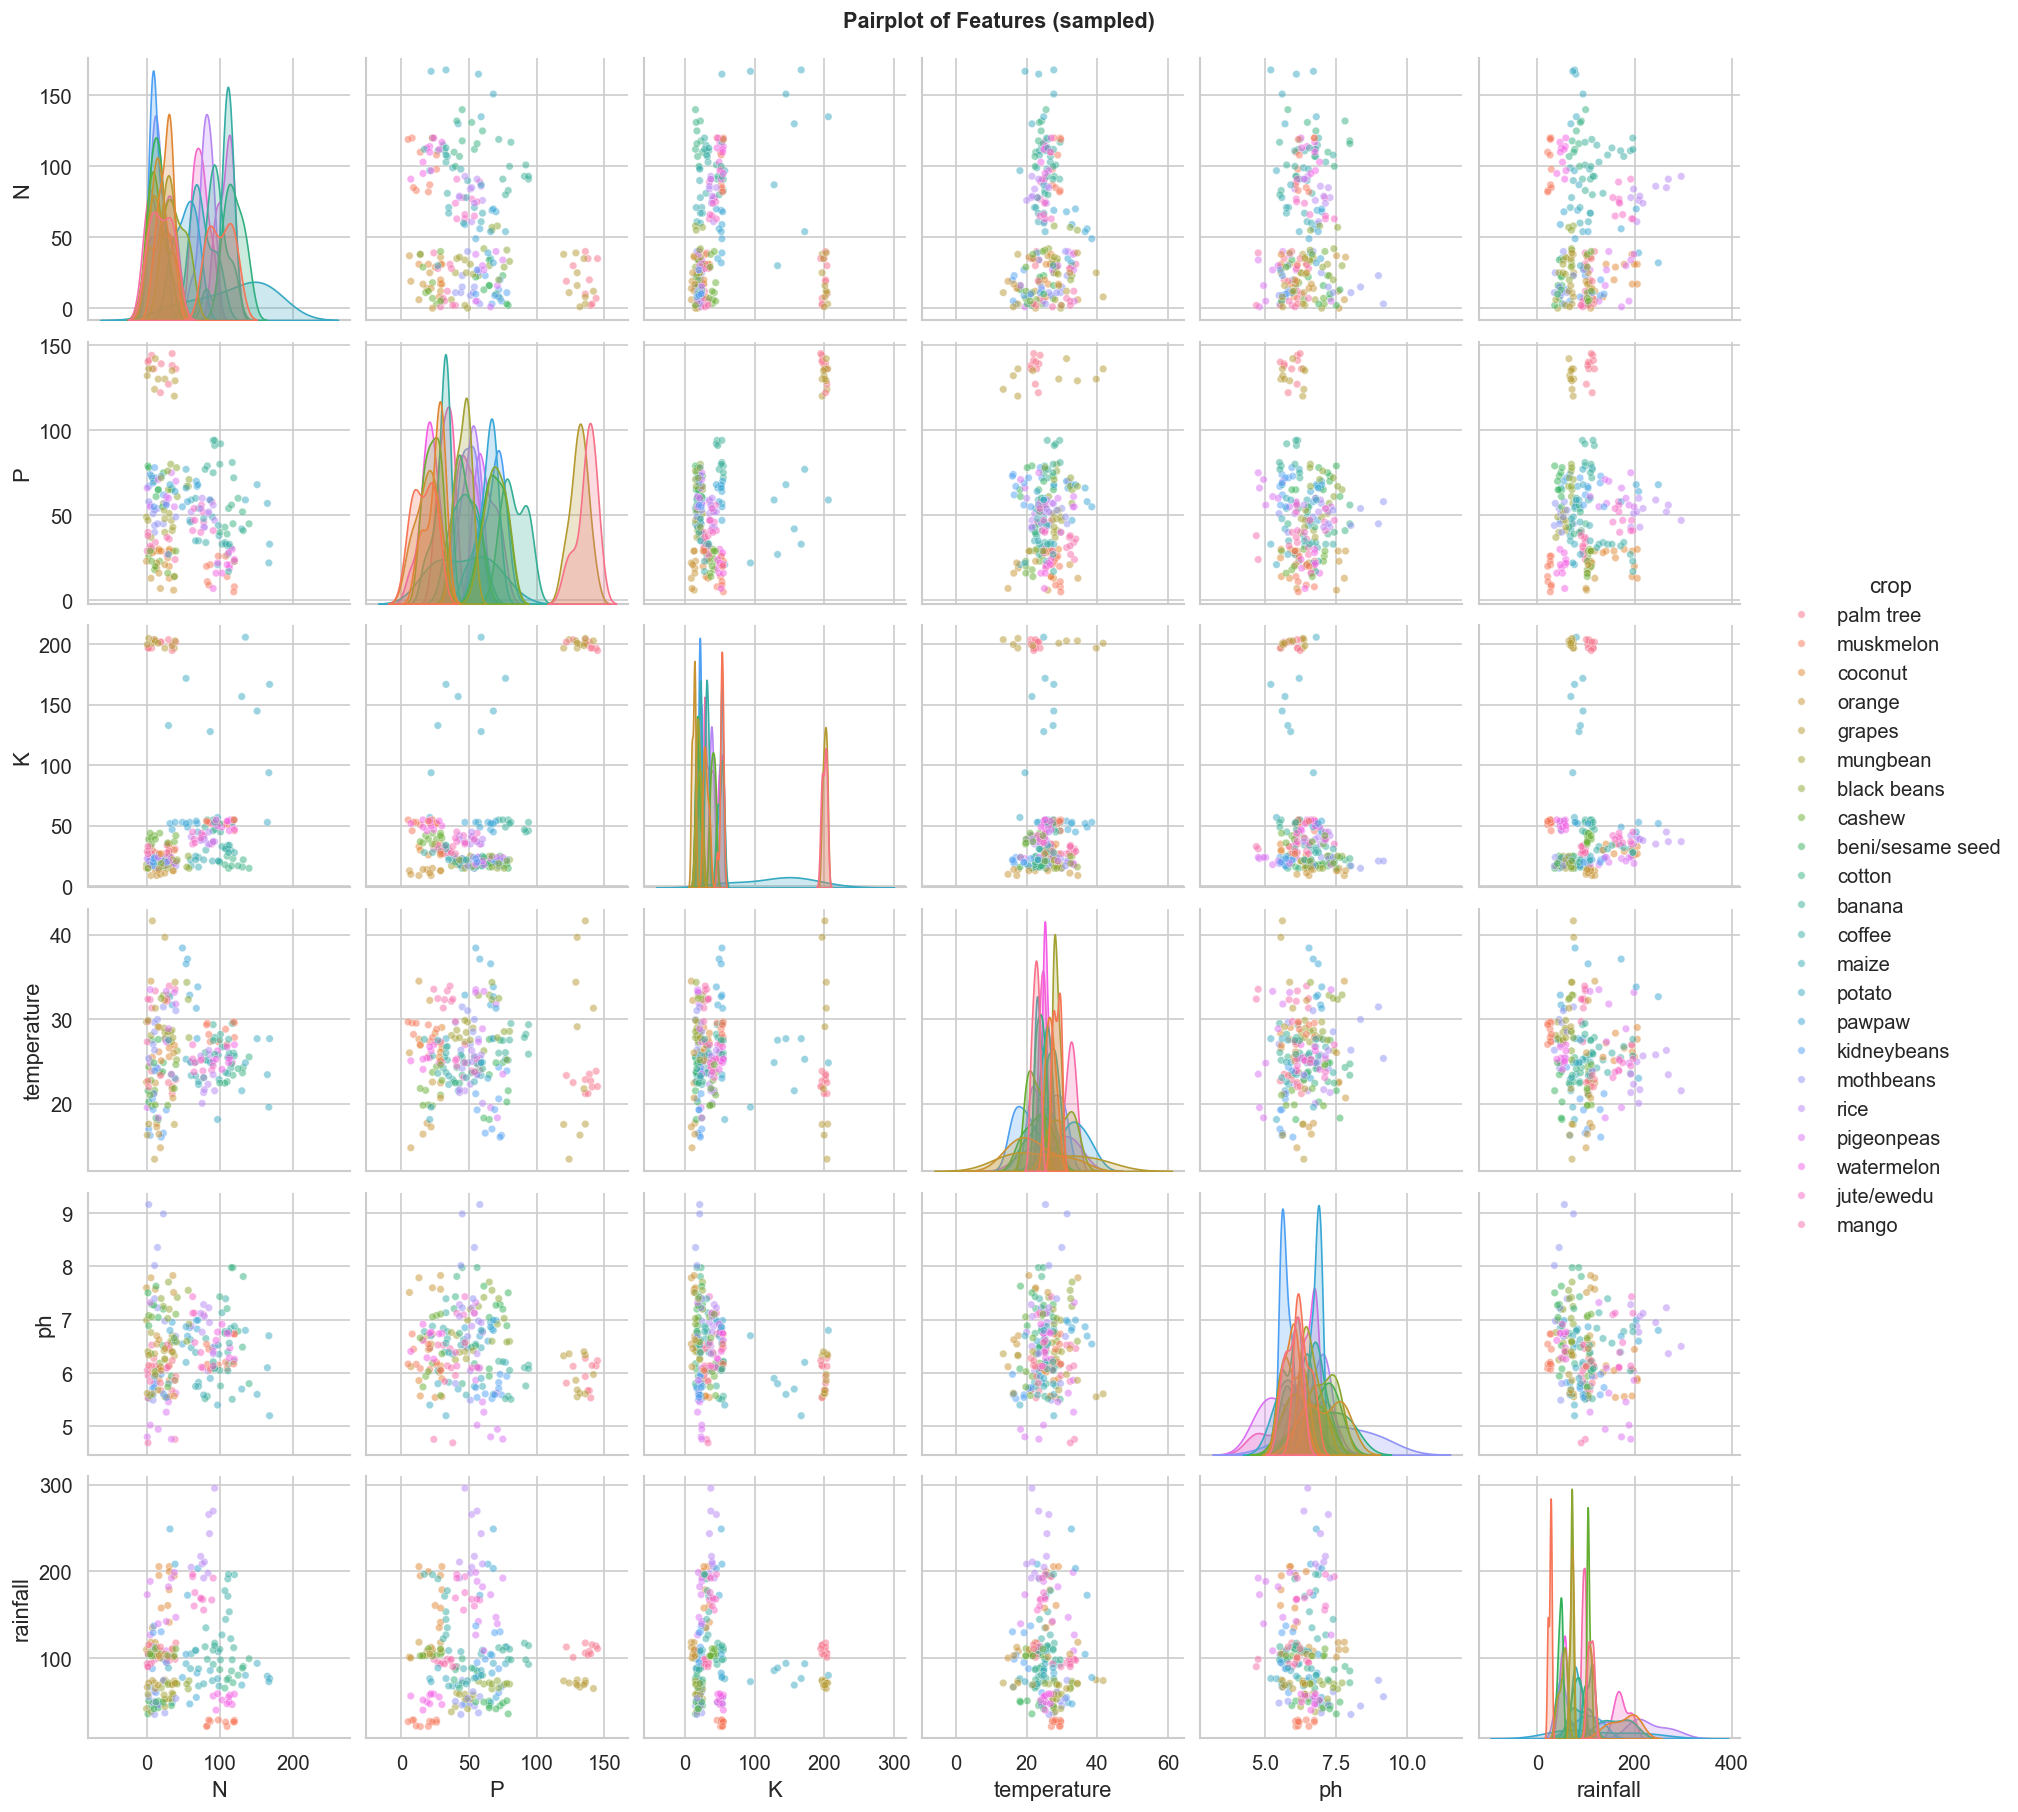

In [16]:
# Pairplot (sampled for speed)
sample = df.sample(frac=1, random_state=42).groupby('crop').head(10).reset_index(drop=True)
pp = sns.pairplot(sample, hue='crop', vars=features, plot_kws={'alpha': 0.5, 's': 20}, diag_kind='kde')
pp.fig.suptitle("Pairplot of Features (sampled)", y=1.01, fontsize=13, fontweight='bold')
plt.show()


## 3. Data Cleaning

**Issues found:**
- `ph` has a maximum of **86.0** — physically impossible (pH scale: 0–14). These are data entry errors.
- All other features are within plausible agronomic ranges.


In [17]:
# Identify & remove pH outliers (pH > 14 is impossible)
print(f"Rows before cleaning : {len(df):,}")
ph_outliers = df[df['ph'] > 14]
print(f"pH > 14 (impossible) : {len(ph_outliers)} rows")
print(ph_outliers[['ph', 'crop']].to_string())
df_clean = df[df['ph'] <= 14].copy()
print(f"Rows after cleaning  : {len(df_clean):,}")


Rows before cleaning : 2,200
pH > 14 (impossible) : 1 rows
        ph    crop
2101  86.0  potato
Rows after cleaning  : 2,199


In [18]:
# Duplicate check
dupes = df_clean.duplicated().sum()
print(f"Duplicate rows: {dupes}")
df_clean = df_clean.drop_duplicates()
print(f"Rows after deduplication: {len(df_clean):,}")


Duplicate rows: 0
Rows after deduplication: 2,199


In [19]:
# Re-inspect after cleaning
print("Clean dataset summary:")
df_clean.describe().round(3)


Clean dataset summary:


,N,P,K,temperature,ph,rainfall
count,2199.000,2199.000,2199.000,2199.000,2199.000,2199.000
mean,53.670,52.303,51.370,25.866,6.402,103.474
std,39.806,33.109,55.832,4.897,0.752,54.969
min,0.000,5.000,5.000,8.826,3.505,20.211
25%,21.000,27.000,20.000,23.189,5.909,64.545
50%,38.000,48.000,32.000,25.735,6.387,94.953
75%,89.000,67.000,49.000,28.578,6.852,124.309
max,179.000,145.000,250.000,43.675,9.935,298.560


In [21]:
# Check class distribution again
print(f"Unique crops : {df_clean['crop'].nunique()}")
print("\nCrop value counts:")
print(df_clean['crop'].value_counts())


Unique crops : 22

Crop value counts:
crop
rice                100
maize               100
coffee              100
jute/ewedu          100
cotton              100
coconut             100
pawpaw              100
orange              100
palm tree           100
muskmelon           100
watermelon          100
grapes              100
mango               100
banana              100
cashew              100
beni/sesame seed    100
black beans         100
mungbean            100
mothbeans           100
pigeonpeas          100
kidneybeans         100
potato               99
Name: count, dtype: int64


## 4. Data Preprocessing, Encoding & Splitting

In [22]:
# Encode target label
le = LabelEncoder()
df_clean['crop_encoded'] = le.fit_transform(df_clean['crop'])
print("Label mapping:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx:2d} → {cls}")


Label mapping:
   0 → banana
   1 → beni/sesame seed
   2 → black beans
   3 → cashew
   4 → coconut
   5 → coffee
   6 → cotton
   7 → grapes
   8 → jute/ewedu
   9 → kidneybeans
  10 → maize
  11 → mango
  12 → mothbeans
  13 → mungbean
  14 → muskmelon
  15 → orange
  16 → palm tree
  17 → pawpaw
  18 → pigeonpeas
  19 → potato
  20 → rice
  21 → watermelon


In [23]:
# Features / target split
FEATURES = ['N', 'P', 'K', 'temperature', 'ph', 'rainfall']
X = df_clean[FEATURES].values
y = df_clean['crop_encoded'].values

# Scale features (critical for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")
print(f"Classes          : {len(le.classes_)}")


Training samples : 1,759
Test samples     : 440
Classes          : 22


## 5. Model Training

Three algorithms chosen for their complementary strengths:
| Model | Why |
|---|---|
| **Random Forest** | Robust ensemble, handles mixed scales, built-in feature importance |
| **Support Vector Machine (SVM)** | Strong on high-dimensional, well-scaled data |
| **Gradient Boosting** | Sequential boosting, typically top performer on tabular data |


In [24]:
# Define models
models = {
    "Random Forest"       : RandomForestClassifier(n_estimators=200, max_depth=None,
                                                   random_state=42, n_jobs=-1),

    "Support Vector Machine": SVC(kernel='rbf', C=10, gamma='scale', probability=True,
                                  random_state=42),

    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                       max_depth=5, random_state=42),
}


In [25]:
# Cross-validation comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<30}  CV mean: {scores.mean():.4f}  std: {scores.std():.4f}")


Random Forest                   CV mean: 0.9807  std: 0.0033
Support Vector Machine          CV mean: 0.9625  std: 0.0075
Gradient Boosting               CV mean: 0.9704  std: 0.0061


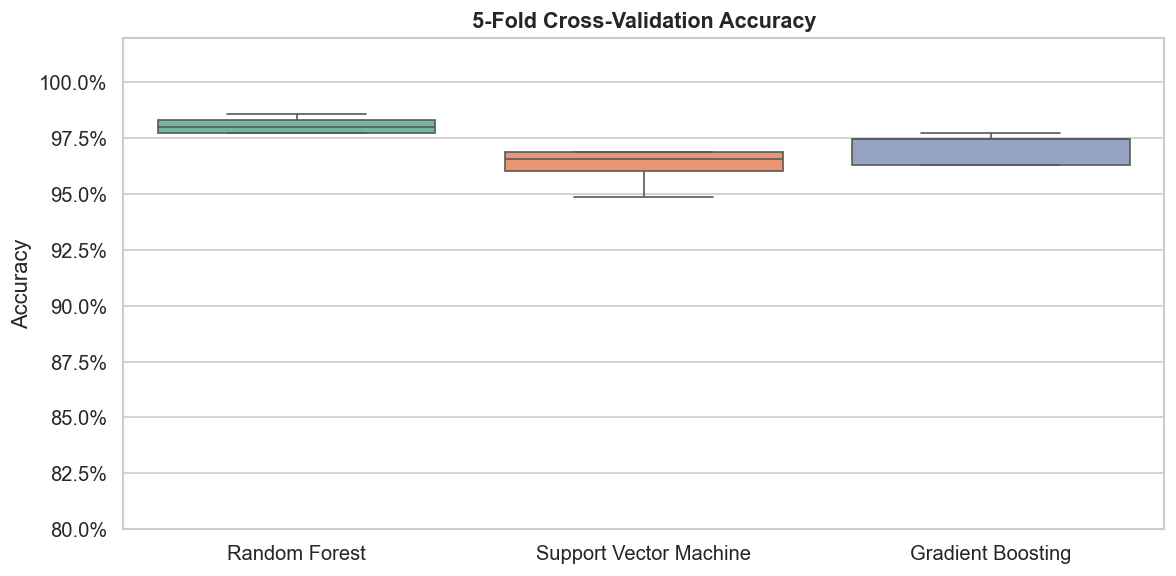

In [26]:
# Visualise CV scores
fig, ax = plt.subplots(figsize=(10, 5))
cv_df = pd.DataFrame(cv_results)
sns.boxplot(data=cv_df, palette='Set2', ax=ax)
ax.set_title("5-Fold Cross-Validation Accuracy", fontsize=13, fontweight='bold')
ax.set_ylabel("Accuracy")
ax.set_ylim(0.8, 1.02)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()


In [27]:
# Train all models on full train set & evaluate on test set
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"model": model, "accuracy": acc, "predictions": y_pred}
    print(f"{name:<30}  Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")


Random Forest                   Test Accuracy: 0.9864 (98.64%)
Support Vector Machine          Test Accuracy: 0.9705 (97.05%)
Gradient Boosting               Test Accuracy: 0.9750 (97.50%)


## 6. Model Evaluation & Comparison

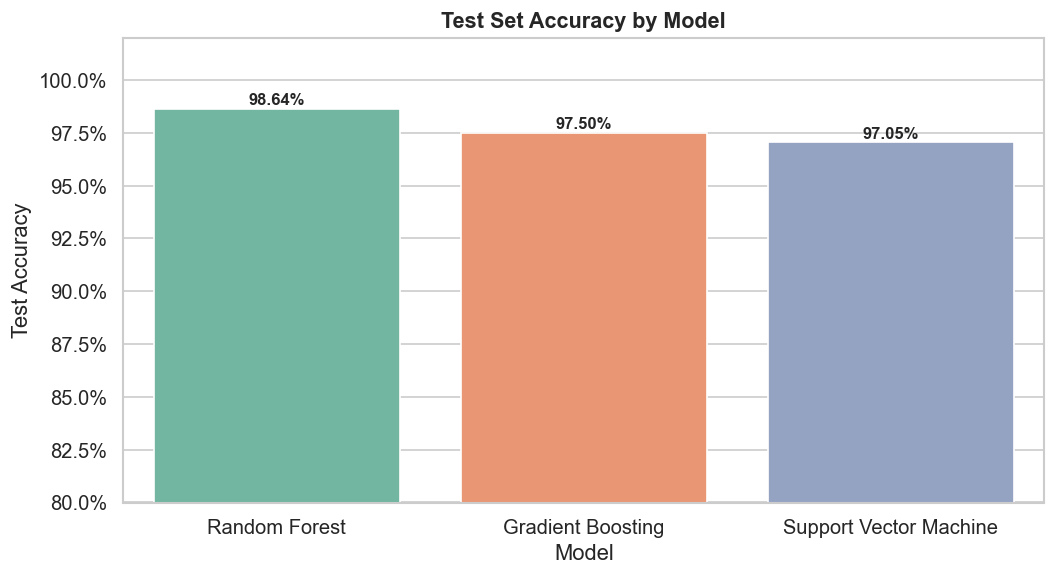

In [28]:
# Accuracy comparison bar chart
acc_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Test Accuracy": [v["accuracy"] for v in results.values()]
}).sort_values("Test Accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = sns.barplot(data=acc_df, x="Model", y="Test Accuracy",
                   palette='Set2', ax=ax, edgecolor='white')
ax.set_ylim(0.8, 1.02)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Test Set Accuracy by Model", fontsize=13, fontweight='bold')
for bar, acc in zip(ax.patches, acc_df["Test Accuracy"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{acc*100:.2f}%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


In [29]:
# Identify best model 
best_name = max(results, key=lambda k: results[k]["accuracy"])
best_model = results[best_name]["model"]
best_acc   = results[best_name]["accuracy"]
best_preds = results[best_name]["predictions"]
print(f"Best Model: {best_name}  |  Test Accuracy: {best_acc*100:.2f}%")


Best Model: Random Forest  |  Test Accuracy: 98.64%


In [30]:
# Classification report for best model
print(f"Classification Report — {best_name}\n")
print(classification_report(y_test, best_preds,
                             target_names=le.classes_, digits=3))


Classification Report — Random Forest

                  precision    recall  f1-score   support

          banana      1.000     1.000     1.000        20
beni/sesame seed      0.952     1.000     0.976        20
     black beans      0.944     0.850     0.895        20
          cashew      1.000     1.000     1.000        20
         coconut      1.000     1.000     1.000        20
          coffee      1.000     1.000     1.000        20
          cotton      1.000     1.000     1.000        20
          grapes      1.000     1.000     1.000        20
      jute/ewedu      0.952     1.000     0.976        20
     kidneybeans      1.000     1.000     1.000        20
           maize      0.952     1.000     0.976        20
           mango      1.000     1.000     1.000        20
       mothbeans      0.900     0.900     0.900        20
        mungbean      1.000     1.000     1.000        20
       muskmelon      1.000     1.000     1.000        20
          orange      1.000     

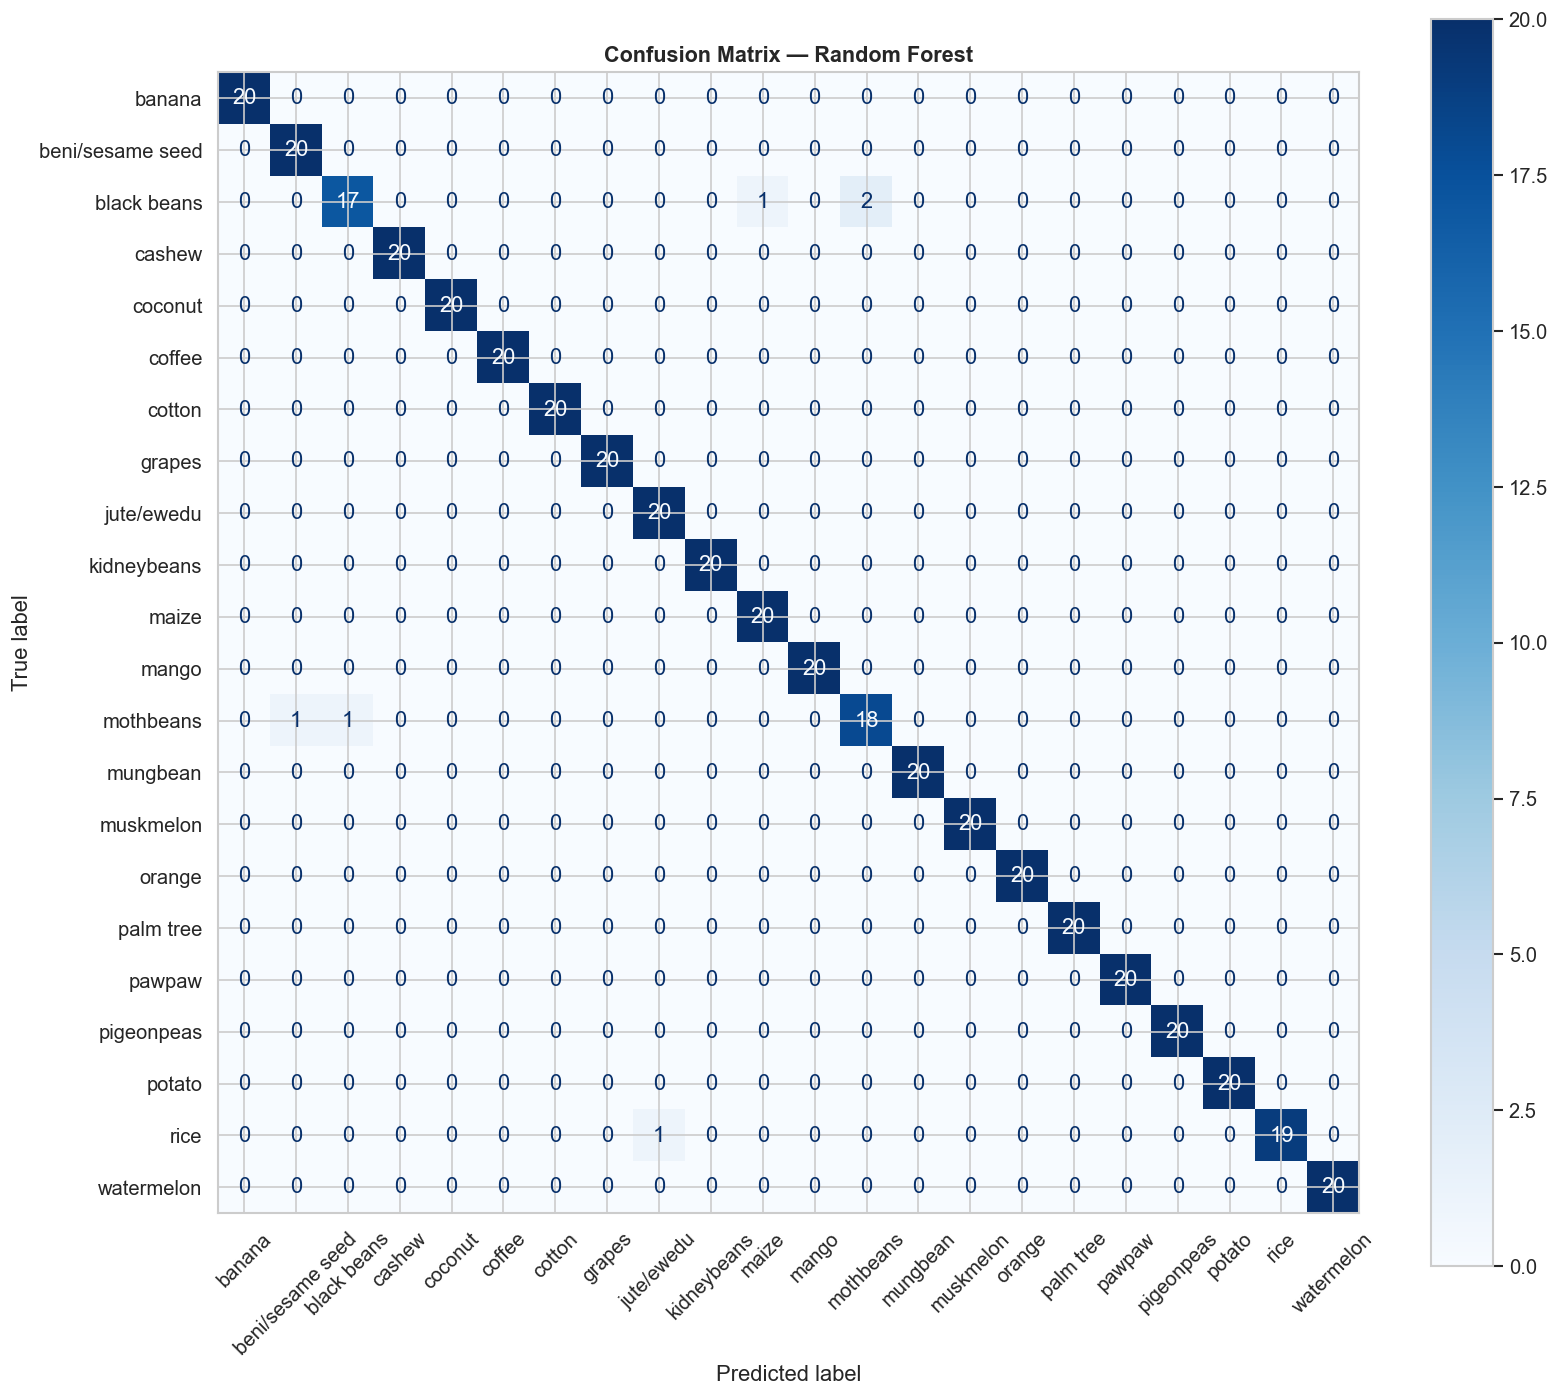

In [31]:
# Confusion matrix
cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


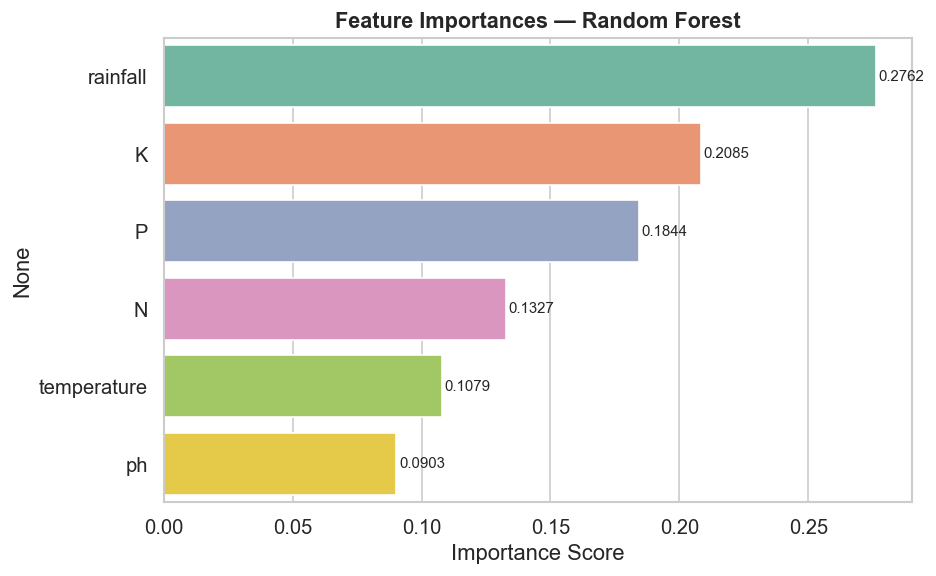

In [32]:
# Feature importance (RF / GB only, skip SVM)
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(x=fi.values, y=fi.index, palette='Set2', ax=ax)
    ax.set_title(f"Feature Importances — {best_name}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Importance Score")
    for bar, val in zip(ax.patches, fi.values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature importance not available for {best_name}")


## 7. Save Artefacts for Streamlit Deployment

In [33]:
# Persist model, scaler, label encoder
os.makedirs("artifacts", exist_ok=True)

joblib.dump(best_model,   f"artifacts/crop_model_{best_name}.pkl")
joblib.dump(scaler,       "artifacts/scaler.pkl")
joblib.dump(le,           "artifacts/label_encoder.pkl")
joblib.dump(FEATURES,     "artifacts/features.pkl")

print("Saved:")
print(f"  artifacts/crop_model_{best_name}.pkl")
print("  artifacts/scaler.pkl")
print("  artifacts/label_encoder.pkl")
print("  artifacts/features.pkl")
print(f"\nDeployed model : {best_name}")
print(f"Test accuracy  : {best_acc*100:.2f}%")
print(f"Classes        : {len(le.classes_)}")


Saved:
  artifacts/crop_model_Random Forest.pkl
  artifacts/scaler.pkl
  artifacts/label_encoder.pkl
  artifacts/features.pkl

Deployed model : Random Forest
Test accuracy  : 98.64%
Classes        : 22


## 8. Project Summary

| Step | Detail |
|---|---|
| Dataset | 2,200 rows, 22 crop classes, 6 numeric features |
| Cleaning | Removed pH > 14 (impossible values), checked duplicates |
| Encoding | `LabelEncoder` for crop target; `StandardScaler` for features |
| Split | 80 / 20 stratified train-test split |
| CV | 5-fold StratifiedKFold |
| Models | Random Forest, SVM (RBF kernel), Gradient Boosting |
| Deployment | Best model serialised → `artifacts/` for Streamlit |

> **Next step:** Run `streamlit run app.py` to launch the prediction web app.
